# Workshop: visualization with `matplotlib`

### Wednesday, March 6, 2024

In today's workshop we'll work a little bit with `matplotlib`, the most popular Python library for visualization.
We will concentrate on the `pyplot` submodule of `matplotlib`, mostly because it is easiest to use, but please bear in mind that `matplotlib` is a lot more than `pyplot`!

If you don't already have `matplotlib` installed, follow the instructions here: https://matplotlib.org/stable/users/installing/index.html

In [3]:
import matplotlib as mp
import matplotlib.pyplot as plt

import numpy as np
import scipy.stats as spstat

## Problem 1: basic plotting

Below is some (fake) data describing two years' worth of monthly sales of a few different products at a fictional cafe: ice cream, hot chocolate and coffee.

Create a plot showing the three products' sales over the two-year span, plotting the ice cream in blue, the hot chocolate in red and the coffee in green.
Include month labels on the x-axis (I've included these in a list `month` in the block below for your convenience), and label your y-axis something sensible (I haven't told you what a unit of sales is, so be as creative or uncreative as you like).
Include a legend, which you should locate outside and to the right of your plot.
You may want to adjust the weights of lines and/or points, depending on resolution and personal taste (and for the sake of practice!).

See here for legend details: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html

See here for details on setting axis tick labels: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html#matplotlib.pyplot.xticks

In [4]:
month = 2*['J','F','M','A','M','J','J','A','S','O','N','D']
T = len(month)
ice_cream = 2 - np.cos(2*np.pi*np.arange(T)/12) + np.random.random(T)-1/2
hot_chocolate = 3 + 2*np.sin(2*np.pi*np.arange(T)/12) + np.random.random(T)-1/2
coffee = 5 + 2*(np.random.random(T)-1/2) - hot_chocolate/4

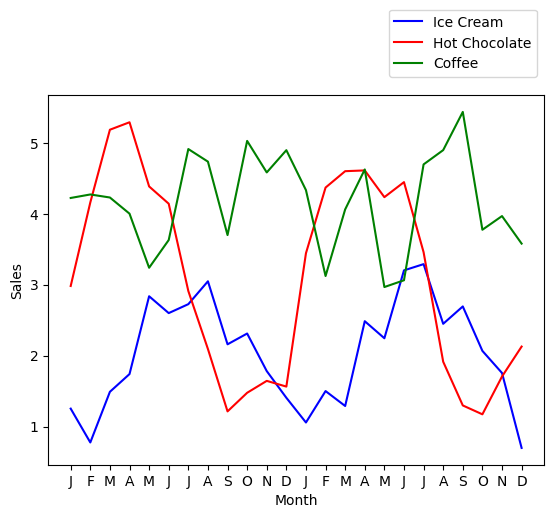

In [42]:
plt.plot(ice_cream, color = 'blue', label = 'Ice Cream')
plt.plot(hot_chocolate, color = 'red', label = 'Hot Chocolate')
plt.plot(coffee, color = 'green', label = 'Coffee')
plt.xticks(np.arange(T), month)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend(loc = 'upper right', bbox_to_anchor = (1.0,1.25))

In [ ]:
plt.plot( ice_cream, color='blue')
plt.plot( hot_chocolate, color='red')
plt.plot( coffee, color='green')
plt.xlabel( 'Month')
plt.ylabel( 'Sales')
# Refer to documentation on plt.xticks
plt.xticks(ticks=range(24), labels=month )
# See the loc keyword; https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html
plt.legend(['Ice cream', 'Hot chocolate', 'Coffee'])

## Problem 2: scatterplots

Here are two sets of two-dimensional data corresponding to two (fictional) groups in a study. Create a scatter plot displaying this data, coloring the `control` group blue and the `treatment` group red.
Include a legend indicating the color correspondence.

In [14]:
n=35
muctrl = np.array([-1,-1])
mutrmt = np.array([ 1, 1])
Sigma = 2*np.array( [[1,1/2],[1/2,1]] )

# Here we are creating two random variable objects, which support, among a
# number of other methods, the method .rvs, which generates draws from the distribution.
# See https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.stats.multivariate_normal.html#scipy.stats.multivariate_normal
# for further reading.

# Fixing random state for reproducibility
np.random.seed(1848)
ctrl_dist = spstat.multivariate_normal(muctrl, Sigma)
trmt_dist = spstat.multivariate_normal(mutrmt, Sigma)

# Now we draw from those two distribution objects that we created.
control = ctrl_dist.rvs( n )
treatmt = trmt_dist.rvs( n )

In [15]:
control # Our data are n-by-2, with each row representing an observation.

array([[-9.02781611e-01, -1.12455513e+00],
       [-5.06324151e-01, -1.69527599e+00],
       [-2.30532880e+00, -2.17631805e+00],
       [-1.44718295e+00,  1.54372139e-01],
       [-6.70993067e-01, -1.05725989e+00],
       [-2.80071976e+00, -1.90627178e+00],
       [-1.54304457e-02, -8.67719109e-01],
       [-8.08904769e-01, -2.47741060e-01],
       [-2.71917637e+00, -2.91356731e+00],
       [-1.72287737e+00, -2.98157014e+00],
       [-1.60151152e+00, -3.67409030e+00],
       [-8.56023662e-01, -3.07246133e+00],
       [-1.27245121e+00, -1.28812385e+00],
       [ 3.61716790e-02, -4.34019824e-01],
       [-6.96661347e-01, -2.43192517e+00],
       [ 5.05661399e-01, -1.44624137e+00],
       [-5.63746456e-01, -1.69589455e+00],
       [ 2.86983107e-01,  1.93718974e+00],
       [ 2.89962112e-01, -4.84040421e-01],
       [-1.02485113e+00, -6.73580105e-01],
       [ 7.25303690e-04,  8.17037398e-01],
       [-1.13119057e+00, -6.15983541e-01],
       [-1.76330472e+00,  7.08457817e-01],
       [-6.

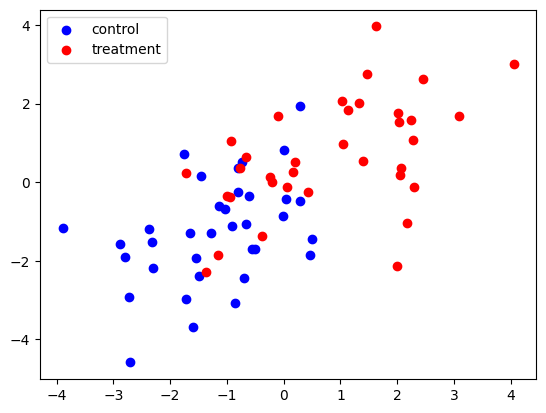

In [28]:
plt.scatter(control[:, 0], control[:, 1], color = 'blue', label = 'control')
plt.scatter(treatmt[:, 0], treatmt[:, 1], color = 'red', label = 'treatment')
plt.legend(loc = 'upper left')

<b>Bonus challenge exercise:</b> Once you've got that plot looking good, adapt the code below (which was itself adapted from this demo page: https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_hist.html#sphx-glr-gallery-lines-bars-and-markers-scatter-hist-py) to create the same scatter plot but with marginal histograms, indicating the marginal x- and y-distributions of the data.

Make sure that the histograms are still colored according to control vs treatment!

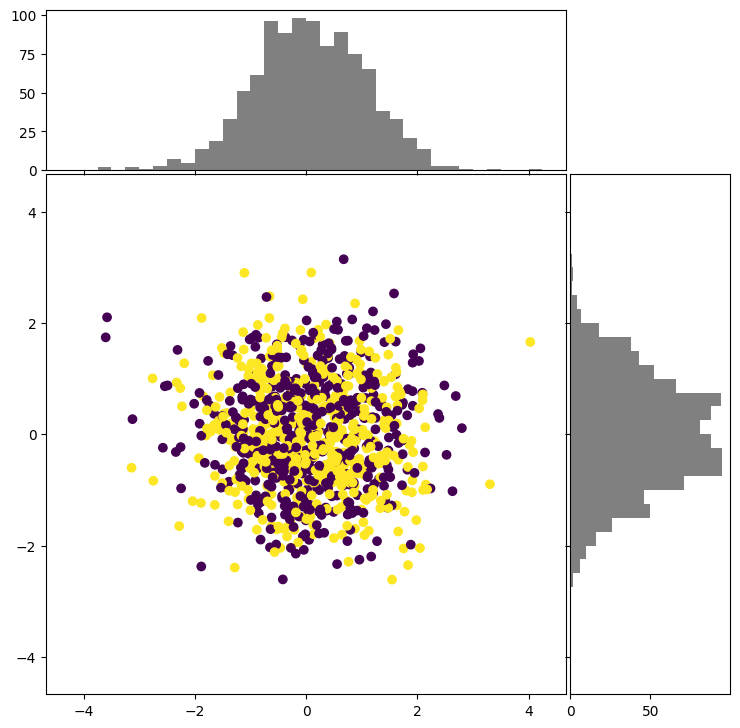

In [49]:
# Fixing random state for reproducibility
np.random.seed(19680801)

# some random data
x = np.random.randn(1000)
y = np.random.randn(1000)
colors = np.random.random(1000) > 0.5

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# start with a square Figure
fig = plt.figure(figsize=(8, 8))

ax = fig.add_axes(rect_scatter)
ax_histx = fig.add_axes(rect_histx, sharex=ax)
ax_histy = fig.add_axes(rect_histy, sharey=ax)

# Turning off labels-- you can turn these labels back on if you want.
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

# Creating the scatter plot
ax.scatter(x, y, c=colors)

# now determine nice limits by hand:
binwidth = 0.25
xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
lim = (int(xymax/binwidth) + 1) * binwidth

bins = np.arange(-lim, lim + binwidth, binwidth)
ax_histx.hist(x, bins=bins, color = 'grey')
ax_histy.hist(y, bins=bins, orientation='horizontal', color = 'grey')

plt.show()

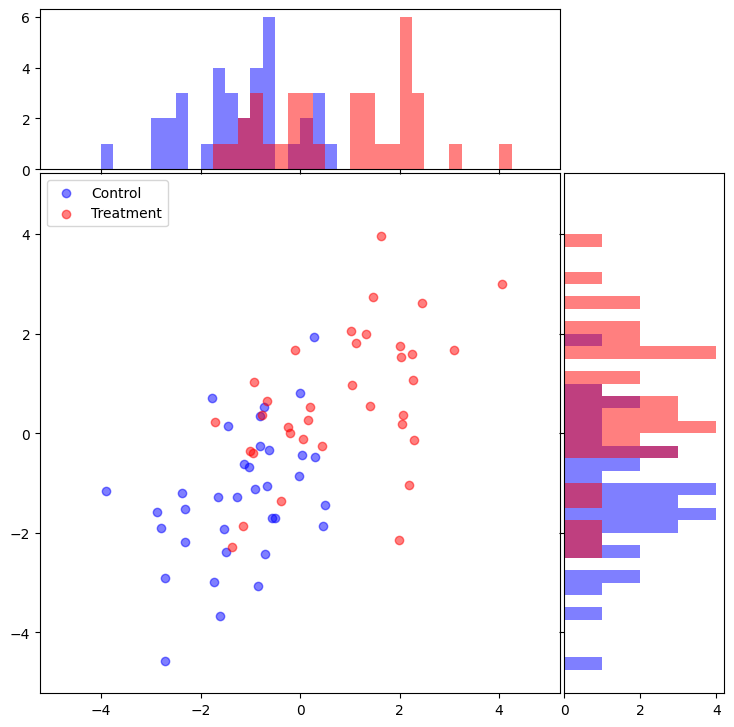

In [55]:
# Fixing random state for reproducibility
np.random.seed(19680801)

x1 = control[:, 0]
y1 = control[:, 1]

x2 = treatmt[:, 0]
y2 = treatmt[:, 1]

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# start with a square Figure
fig = plt.figure(figsize=(8, 8))

ax = fig.add_axes(rect_scatter)
ax_histx = fig.add_axes(rect_histx, sharex=ax)
ax_histy = fig.add_axes(rect_histy, sharey=ax)

# Turning off labels-- you can turn these labels back on if you want.
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

# Creating the scatter plot
ax.scatter(x1, y1, c='blue', alpha = 0.5)
ax.scatter(x2, y2, c='red', alpha = 0.5)

# now determine nice limits by hand:
binwidth = 0.25
xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
lim = (int(xymax/binwidth) + 1) * binwidth

bins = np.arange(-lim, lim + binwidth, binwidth)
ax_histx.hist(x1, bins=bins, color='blue', alpha=0.5)
ax_histx.hist(x2, bins=bins, color='red', alpha=0.5)
ax_histy.hist(y1, bins=bins, orientation='horizontal', color='blue', alpha=0.5)
ax_histy.hist(y2, bins=bins, orientation='horizontal', color='red', alpha=0.5)

ax.legend(['Control', 'Treatment'], loc = 'upper left')

plt.show()

## Problem 3: contours

As we saw in lecture, drawing contour lines in `matplotlib` is a bit complicated.

Use the contour plotting functionality to plot a black circle of radius 2 in a plot that shows x- and y-axes ranging from -3 to 3.

This example from the matplotlib documentation might be helpful. Note that you don't need to bother with any of the `ax` business-- `plt.contour(X,Y,Z)` is enough! https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_demo.html

You may also want to refer to this page, if your plot's axes are behaving strangely: https://matplotlib.org/stable/gallery/subplots_axes_and_figures/axis_equal_demo.html

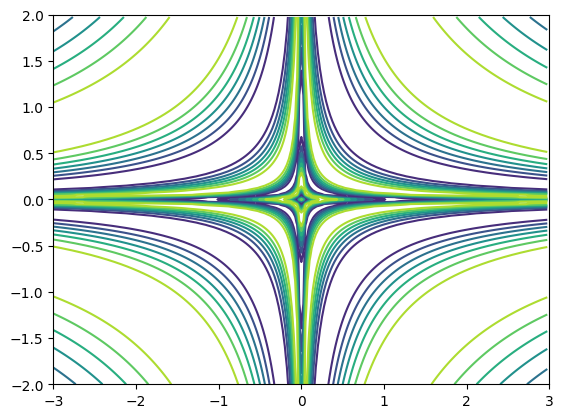

In [75]:
delta = 0.025
x = np.arange(-3.0, 3.0, delta)
y = np.arange(-2.0, 2.0, delta)
xx, yy = np.meshgrid(x, y)
zz = np.sin(np.log(xx**2) + np.log(yy**2))
plt.contour(xx, yy, zz)
plt.xlim(-3, 3)
plt.ylim(-2, 2)
plt.show()